# Week 1: Lab Assignment - Multi-Armed Bandits

**NOTE:** This first lab is not graded.

## Objectives
In this lab, you will:
1. Implement a multi-armed bandit environment from scratch
2. Implement and compare different exploration strategies
3. Analyze the exploration-exploitation tradeoff
4. Understand the impact of different parameters on learning

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

# Set random seed for reproducibility
np.random.seed(42)

## Part 1: Implement the Bandit Environment

Create a `MultiArmedBandit` class that simulates a bandit problem with multiple arms.

In [3]:
class MultiArmedBandit:
    """
    Multi-Armed Bandit environment.
    
    Each arm has a Gaussian reward distribution with a specific mean and standard deviation.
    """
    
    def __init__(self, n_arms: int, means: List[float] = None, std: float = 1.0):
        """
        Initialize the bandit.
        
        Args:
            n_arms: Number of arms
            means: List of mean rewards for each arm. If None, randomly generate.
            std: Standard deviation of reward distributions
        """
        self.n_arms = n_arms
        self.std = std
        
        if means is None:
            # TODO: Generate random means from a normal distribution N(0, 1)
            self.means = np.random.normal(0, 1, n_arms)  
        else:
            self.means = np.array(means)
        
        # Track which arm is optimal
        self.optimal_arm = np.argmax(self.means)
    
    def pull(self, arm: int) -> float:
        """
        Pull an arm and receive a reward.
        
        Args:
            arm: Index of the arm to pull (0 to n_arms-1)
            
        Returns:
            reward: Reward sampled from the arm's distribution
        """
        # TODO: Return a reward sampled from N(means[arm], std^2)
        reward = np.random.normal(self.means[arm], self.std)  # Replace with your implementation
        return reward
    
    def get_optimal_value(self) -> float:
        """Return the expected reward of the optimal arm."""
        return self.means[self.optimal_arm]


# Test your implementation
bandit = MultiArmedBandit(n_arms=5, means=[0.5, 1.2, 0.8, 2.1, 1.5])
print(f"Bandit means: {bandit.means}")
print(f"Optimal arm: {bandit.optimal_arm} with mean {bandit.get_optimal_value():.2f}")
print(f"\nSample rewards from arm {bandit.optimal_arm}: ", [f"{bandit.pull(bandit.optimal_arm):.2f}" for _ in range(5)])

Bandit means: [0.5 1.2 0.8 2.1 1.5]
Optimal arm: 3 with mean 2.10

Sample rewards from arm 3:  ['2.60', '1.96', '2.75', '3.62', '1.87']


## Part 2: Implement Epsilon-Greedy Agent

Create an agent that uses the epsilon-greedy strategy for action selection.

In [13]:
class EpsilonGreedyAgent:
    """
    Agent using epsilon-greedy action selection.
    """
    
    def __init__(self, n_arms: int, epsilon: float = 0.1, initial_value: float = 0.0):
        """
        Initialize the agent.
        
        Args:
            n_arms: Number of arms
            epsilon: Exploration probability
            initial_value: Initial Q-value estimates for all arms
        """
        self.n_arms = n_arms
        self.epsilon = epsilon
        
        # Q-values: estimated value of each arm
        self.Q = np.ones(n_arms) * initial_value
        
        # Count how many times each arm was pulled
        self.N = np.zeros(n_arms)
    
    def select_action(self) -> int:
        """
        Select an action using epsilon-greedy strategy.
        
        Returns:
            action: Selected arm index
        """
        # TODO: Implement epsilon-greedy action selection
        # With probability epsilon, choose a random arm
        # Otherwise, choose the arm with highest Q-value
        # Hint: Use np.random.random() and np.argmax()
                
        action = np.random.randint(self.n_arms) if np.random.random() < self.epsilon else np.argmax(self.Q)
        return action
    
    def update(self, action: int, reward: float):
        """
        Update Q-value estimate after observing a reward.
        
        Args:
            action: The arm that was pulled
            reward: The observed reward
        """
        # TODO: Update the Q-value using incremental mean formula:
        # Q_new = Q_old + (1/N) * (reward - Q_old)
        # where N is the number of times this arm was pulled
        
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]


# Test your implementation
agent = EpsilonGreedyAgent(n_arms=5, epsilon=0.1)
print(f"Initial Q-values: {agent.Q}")

# Simulate a few pulls
for _ in range(1000):
    action = agent.select_action()
    reward = np.random.randn() + 1.0  # Dummy reward
    agent.update(action, reward)

print(f"\nAfter 100 steps:")
print(f"Q-values: {agent.Q}")
print(f"Arm counts: {agent.N}")

Initial Q-values: [2. 2. 2. 2. 2.]

After 100 steps:
Q-values: [1.03046045 1.01704421 0.7369084  1.01039823 0.96478788]
Arm counts: [653.  43.  24. 237.  43.]


## Part 3: Implement Upper Confidence Bound (UCB) Agent

The UCB algorithm provides a principled way to balance exploration and exploitation.

**UCB Action Selection:**
$$A_t = \arg\max_a \left[ Q_t(a) + c \sqrt{\frac{\ln t}{N_t(a)}} \right]$$

Where:
- $Q_t(a)$ is the estimated value of action $a$
- $N_t(a)$ is the number of times action $a$ was selected
- $t$ is the total time step
- $c$ is the exploration parameter (typically $c=2$)

In [21]:
class UCBAgent:
    """
    Agent using Upper Confidence Bound (UCB) action selection.
    """
    
    def __init__(self, n_arms: int, c: float = 2.0, initial_value: float = 5.0):
        """
        Initialize the agent.
        
        Args:
            n_arms: Number of arms
            c: Exploration parameter
            initial_value: Initial Q-value estimates
        """
        self.n_arms = n_arms
        self.c = c
        
        self.Q = np.ones(n_arms) * initial_value
        self.N = np.zeros(n_arms)
        self.t = 0  # Total time steps
    
    def select_action(self) -> int:
        """
        Select an action using UCB.
        
        Returns:
            action: Selected arm index
        """
        self.t += 1
        
        # TODO: Implement UCB action selection
        # For arms that haven't been pulled yet (N[a] == 0), give them infinite value
        # to ensure they are explored first
        # For other arms, calculate UCB = Q[a] + c * sqrt(ln(t) / N[a])
        # Return the arm with highest UCB value
        # Hint: Use np.where() to handle division by zero
        action= np.argmax(self.Q + self.c * np.sqrt(np.log(self.t) / (self.N + 1e-100)))  # Avoid division by zero
        
#       --- IGNORE ---        
#       action = np.argmax(np.where(self.N == 0, float('inf'), self.Q + self.c * np.sqrt(np.log(self.t) / self.N)))
        return action
    
    def update(self, action: int, reward: float):
        """
        Update Q-value estimate.
        
        Args:
            action: The arm that was pulled
            reward: The observed reward
        """
        # TODO: Same update rule as epsilon-greedy
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]


# Test your implementation
agent = UCBAgent(n_arms=5, c=2.0)
print(f"Initial Q-values: {agent.Q}")

# Simulate a few pulls
for _ in range(1000):
    action = agent.select_action()
    reward = np.random.randn() + 1.0
    agent.update(action, reward)

print(f"\nAfter 1000 steps:")
print(f"Q-values: {agent.Q}")
print(f"Arm counts: {agent.N}")

Initial Q-values: [5. 5. 5. 5. 5.]

After 1000 steps:
Q-values: [0.94912711 0.99475363 1.09586762 1.01588523 1.05591431]
Arm counts: [137. 168. 288. 186. 221.]


## Part 4: Experiment Runner

Create a function to run experiments and collect metrics.

In [35]:
def run_experiment(agent_class, agent_params: dict, bandit: MultiArmedBandit, 
                   n_steps: int = 1000) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Run a single experiment with a given agent and bandit.
    
    Args:
        agent_class: The agent class to use (EpsilonGreedyAgent or UCBAgent)
        agent_params: Dictionary of parameters to pass to agent constructor
        bandit: The bandit environment
        n_steps: Number of steps to run
        
    Returns:
        rewards: Array of rewards obtained at each step
        optimal_actions: Binary array indicating if optimal action was taken
        q_values_final: Final Q-value estimates
    """
    # TODO: Implement the experiment runner
    # 1. Create the agent
    agent = agent_class(**agent_params)
    
    #Allocote results arrays
    rewards = np.zeros(n_steps)
    optimal_actions = np.zeros(n_steps)

    # 2. For each step:
    #    - Select an action
    #    - Pull the bandit arm
    #    - Update the agent
    #    - Record the reward
    #    - Record if optimal action was taken
    for step in range(n_steps):
        action = agent.select_action()
        reward = bandit.pull(action)
        agent.update(action, reward)
        
        rewards[step] = reward
        optimal_actions[step] = 1 if action == bandit.optimal_arm else 0
    # 3. Return collected metrics
        
    return rewards, optimal_actions, agent.N.copy()


def run_multiple_experiments(agent_class, agent_params: dict, n_experiments: int = 100, 
                            n_steps: int = 1000, n_arms: int = 10) -> Tuple[np.ndarray, np.ndarray]:
    """
    Run multiple experiments and average the results.
    
    Args:
        agent_class: The agent class to use
        agent_params: Parameters for the agent
        n_experiments: Number of experiments to run
        n_steps: Steps per experiment
        n_arms: Number of arms in the bandit
        
    Returns:
        avg_rewards: Average rewards across experiments
        avg_optimal: Average percentage of optimal actions
    """
    all_rewards = np.zeros((n_experiments, n_steps))
    all_optimal = np.zeros((n_experiments, n_steps))
    
    for i in range(n_experiments):
        # Create a new bandit for each experiment
        bandit = MultiArmedBandit(n_arms=n_arms)
        
        rewards, optimal_actions, _ = run_experiment(agent_class, agent_params, bandit, n_steps)
        
        all_rewards[i] = rewards
        all_optimal[i] = optimal_actions
    
    return np.mean(all_rewards, axis=0), np.mean(all_optimal, axis=0)


# Test with a simple case
test_bandit = MultiArmedBandit(n_arms=5, means=[0.5, 1.2, 0.8, 2.1, 1.5])
rewards, optimal, arm_counts = run_experiment(EpsilonGreedyAgent, {'n_arms': 5, 'epsilon': 0.1}, test_bandit, n_steps=10)
print(f"Test run completed: {len(rewards)} rewards collected")
print(f"Average reward: {np.mean(rewards):.3f}")
print(f"Optimal action rate: {np.mean(optimal)*100:.1f}%")
print(f"\nArm pull counts: {arm_counts}")
print(f"Arm means:       {test_bandit.means}")

Test run completed: 10 rewards collected
Average reward: 1.119
Optimal action rate: 30.0%

Arm pull counts: [1. 5. 1. 3. 0.]
Arm means:       [0.5 1.2 0.8 2.1 1.5]


## Part 5: Compare Epsilon-Greedy with Different Epsilon Values

Compare the performance of epsilon-greedy with ε ∈ {0, 0.01, 0.1, 0.3}

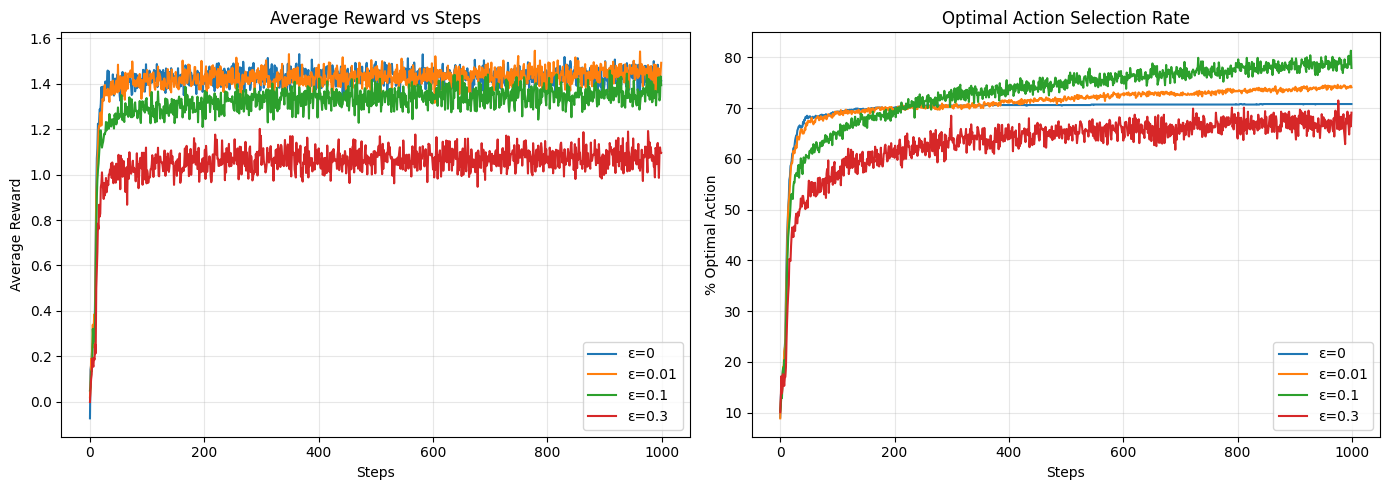

In [41]:
# TODO: Run experiments for different epsilon values

epsilon_values = [0, 0.01, 0.1, 0.3]
n_experiments = 1000
n_steps = 1000

results = {}

# Your implementation here
# For each epsilon value:
#   - Run multiple experiments
#   - Store average rewards and optimal action rates
for eps in epsilon_values:
    avg_rewards, avg_optimal = run_multiple_experiments(
        EpsilonGreedyAgent,
        {'n_arms': 10, 'epsilon': eps},
        n_experiments=n_experiments,
        n_steps=n_steps,
        n_arms=10
    )
    results[eps] = (avg_rewards, avg_optimal)   

# Plotting
plt.figure(figsize=(14, 5))

# Plot 1: Average reward over time
plt.subplot(1, 2, 1)
for eps in epsilon_values:
    # TODO: Plot the average reward curve for this epsilon
    avg_rewards, _ = results[eps]
    plt.plot(avg_rewards, label=f"ε={eps}") 

plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.title('Average Reward vs Steps')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Optimal action percentage
plt.subplot(1, 2, 2)
for eps in epsilon_values:
    # TODO: Plot the optimal action percentage for this epsilon
    _, avg_optimal = results[eps]
    plt.plot(avg_optimal * 100, label=f"ε={eps}")

plt.xlabel('Steps')
plt.ylabel('% Optimal Action')
plt.title('Optimal Action Selection Rate')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 6: Compare Epsilon-Greedy vs UCB

Compare epsilon-greedy (ε=0.1) with UCB (c=2.0)

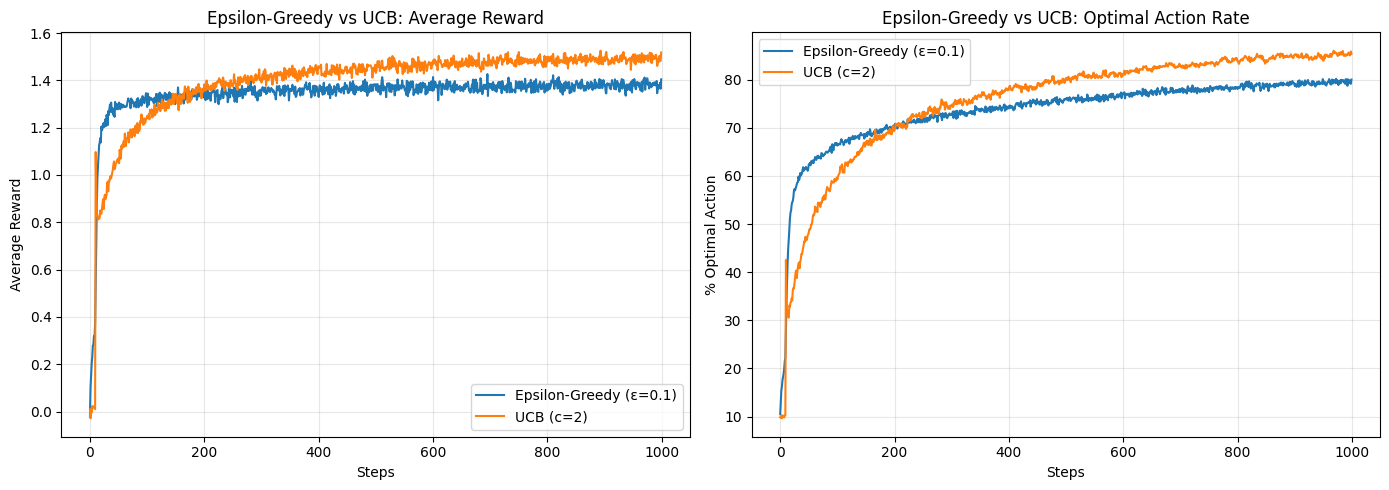


Final Performance (last 100 steps average):
Epsilon-Greedy (ε=0.1): Average Reward = 1.380, Optimal Action Rate = 79.4%
UCB (c=2): Average Reward = 1.491, Optimal Action Rate = 85.0%


In [40]:
# TODO: Run experiments comparing epsilon-greedy and UCB

# Run epsilon-greedy
rewards_egreedy, optimal_egreedy = run_multiple_experiments(
    EpsilonGreedyAgent,
    {'n_arms': 10, 'epsilon': 0.1},
    n_experiments=5000,
    n_steps=1000,
    n_arms=10
)

# Run UCB
rewards_ucb, optimal_ucb = run_multiple_experiments(
    UCBAgent,
    {'n_arms': 10, 'c': 2},
    n_experiments=5000,
    n_steps=1000,
    n_arms=10
)

# Plotting
plt.figure(figsize=(14, 5))

# Plot 1: Average reward
plt.subplot(1, 2, 1)
# TODO: Plot both strategies
plt.plot(rewards_egreedy, label="Epsilon-Greedy (ε=0.1)")
plt.plot(rewards_ucb, label="UCB (c=2)")
plt.xlabel('Steps')
plt.ylabel('Average Reward')
plt.title('Epsilon-Greedy vs UCB: Average Reward')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Optimal action rate
plt.subplot(1, 2, 2)
# TODO: Plot both strategies
plt.plot(optimal_egreedy * 100, label="Epsilon-Greedy (ε=0.1)")
plt.plot(optimal_ucb * 100, label="UCB (c=2)")
plt.xlabel('Steps')
plt.ylabel('% Optimal Action')
plt.title('Epsilon-Greedy vs UCB: Optimal Action Rate')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final statistics
print(f"\nFinal Performance (last 100 steps average):")
# TODO: Print average rewards and optimal action rates for both strategies
print(f"Epsilon-Greedy (ε=0.1): Average Reward = {np.mean(rewards_egreedy[-100:]):.3f}, Optimal Action Rate = {np.mean(optimal_egreedy[-100:]) * 100:.1f}%")
print(f"UCB (c=2): Average Reward = {np.mean(rewards_ucb[-100:]):.3f}, Optimal Action Rate = {np.mean(optimal_ucb[-100:]) * 100:.1f}%")

## Part 7: Analysis Questions

Answer the following questions based on your experiments:

1. **Effect of epsilon:**
   - What happens when ε = 0 (pure greedy)?
   - What happens when ε is too large (e.g., 0.3)?
   - What is the best epsilon value for this problem?

2. **Epsilon-Greedy vs UCB:**
   - Which strategy converges faster initially?
   - Which strategy achieves better long-term performance?
   - When would you prefer UCB over epsilon-greedy?

3. **Trade-offs:**
   - What is the main advantage of epsilon-greedy?
   - What is the main advantage of UCB?
   - Can you think of scenarios where epsilon-greedy would be preferred?

**Write your answers in the markdown cell below:**

### Your Answers:

1. **Effect of epsilon:**
   - ε = 0: 
   - ε = 0.3: 
   - Best ε: 

2. **Epsilon-Greedy vs UCB:**
   - Initial convergence: 
   - Long-term performance: 
   - When to use UCB: 

3. **Trade-offs:**
   - Epsilon-greedy advantage: 
   - UCB advantage: 
   - Scenarios for epsilon-greedy: 

## Bonus Challenge (Optional)

If you finish early, try implementing one of these:

1. **Decaying Epsilon:** Implement epsilon-greedy where ε decreases over time
2. **Optimistic Initial Values:** Test how initial Q-values affect exploration
3. **Gradient Bandit:** Implement a policy gradient approach for bandits
4. **Non-stationary Bandits:** Modify the bandit so arm means change over time

In [ ]:
# Your bonus implementation here